# Basic Regression with NAMpy

This notebook demonstrates how to use NAMpy for regression tasks. We'll train a Neural Additive Model (NAM) on a synthetic dataset and visualize the learned shape functions.

## Setup

First, let's import the necessary libraries.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing, make_regression
from sklearn.model_selection import train_test_split

# Import NAMpy models
from nampy.models import NAMRegressor

# Set random seed for reproducibility
np.random.seed(42)


## 1. Synthetic Data Example

Let's start with a simple synthetic dataset to understand how NAMs work.

In [2]:
# Generate synthetic regression data
X, y = make_regression(
    n_samples=10000,
    n_features=5,
    n_informative=5,
    noise=10.0,
    random_state=42
)

# Convert to DataFrame for better visualization
feature_names = [f'feature_{i}' for i in range(X.shape[1])]
X_df = pd.DataFrame(X, columns=feature_names)

print(f"Dataset shape: {X_df.shape}")
print(f"Target range: [{y.min():.2f}, {y.max():.2f}]")
X_df.head()

Dataset shape: (10000, 5)
Target range: [-488.33, 534.63]


,feature_0,feature_1,feature_2,feature_3,feature_4
0,0.015984,-0.250427,-0.196782,-1.532182,0.511526
1,0.824820,-1.183873,0.497429,0.213996,2.292212
2,-1.560242,1.854662,-0.054351,-0.917028,1.131299
3,-0.162704,-0.871193,0.745361,0.093523,0.072153
4,-0.438105,-0.662554,1.033911,0.509996,-0.407000


## 4. Real-World Dataset: California Housing

Let's apply NAMpy to a real-world dataset - the California Housing dataset.

In [ ]:
# Load California Housing dataset
housing = fetch_california_housing()
X_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
y_housing = housing.target

print(f"Dataset shape: {X_housing.shape}")
print(f"\nFeature names: {housing.feature_names}")
print("\nTarget: Median house value (in $100,000s)")
X_housing.describe()


Dataset shape: (20640, 8)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target: Median house value (in $100,000s)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [ ]:
# Split the data
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train_h)}")
print(f"Test samples: {len(X_test_h)}")

Training samples: 16512
Test samples: 4128


In [ ]:
# Train NAM on California Housing
model_housing = NAMRegressor(
    numerical_preprocessing="ple",  # Piecewise Linear Encoding
    n_bins=50,
    dropout=0.2,
    layer_sizes=[128, 64, 32],
)

model_housing.fit(
    X_train_h,
    y_train_h,
    max_epochs=100,
    lr=1e-3,
    patience=10,
    batch_size=256
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/home/ad32/miniconda3/envs/nampy/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/ad32/projects/test/NAMpy/docs/notebooks/model_checkpoints exists and is not empty.


┏━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss_fct │ MSELoss │      0 │ train │     0 │
│ 1 │ model    │ NAM     │  135 K │ train │     0 │
└───┴──────────┴─────────┴────────┴───────┴───────┘

Trainable params: 135 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 135 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 69                                                                                          
Modules in eval mode: 1                                                                                            
Total FLOPs: 0

Output()

/home/ad32/miniconda3/envs/nampy/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.p
y:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of 
the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

/home/ad32/miniconda3/envs/nampy/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.p
y:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value 
of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

/home/ad32/miniconda3/envs/nampy/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:534: Found 1 
module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is 
intentional, you can ignore this warning.

,dropout,0.2
,layer_sizes,"[128, 64, ...]"
,preprocessor__n_bins,50
,preprocessor__numerical_preprocessing,'ple'
,preprocessor__categorical_preprocessing,'int'
,preprocessor__use_decision_tree_bins,False
,preprocessor__binning_strategy,'uniform'
,preprocessor__task,'regression'
,preprocessor__cat_cutoff,0.03
,preprocessor__treat_all_integers_as_numerical,False
,preprocessor__degree,3


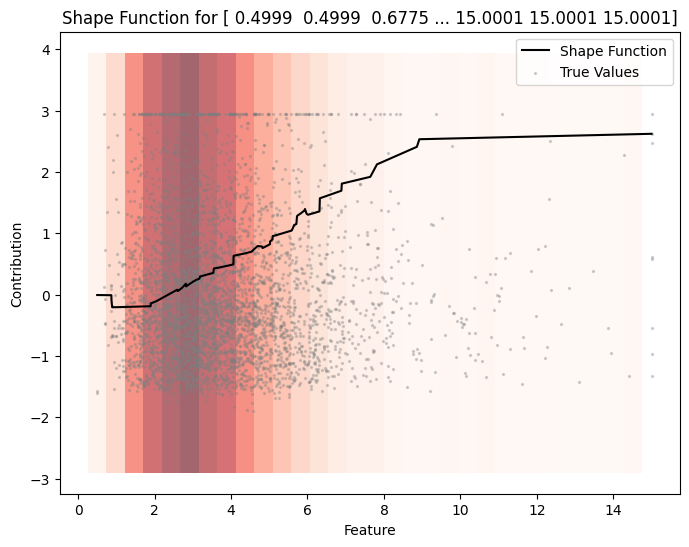

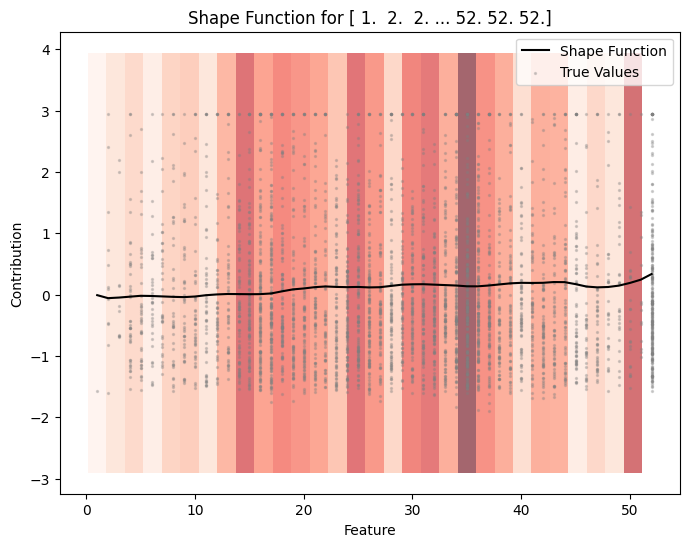

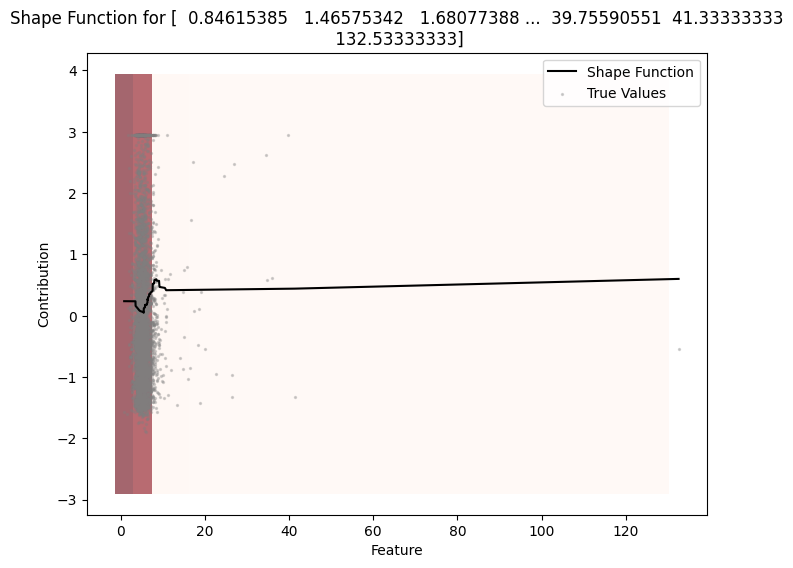

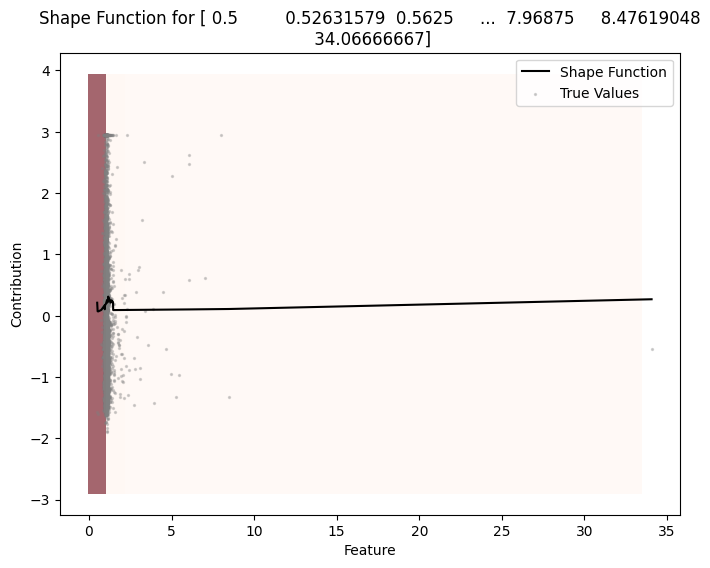

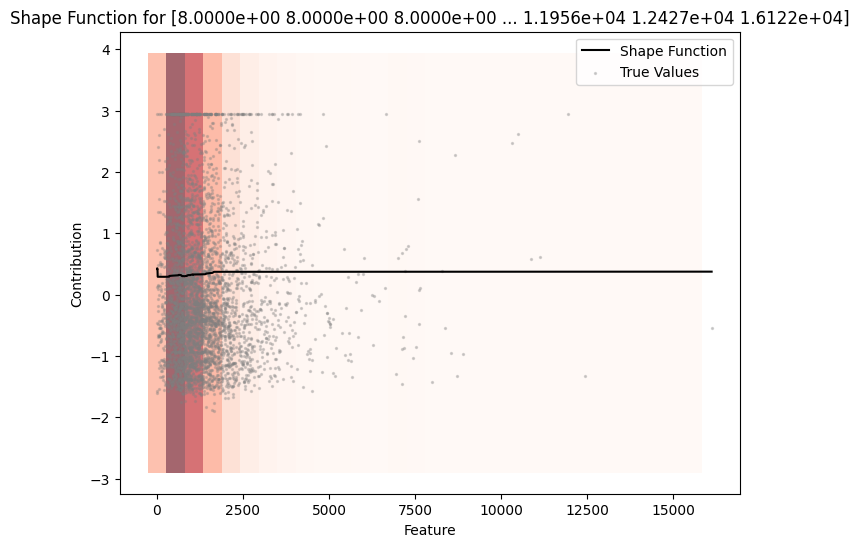

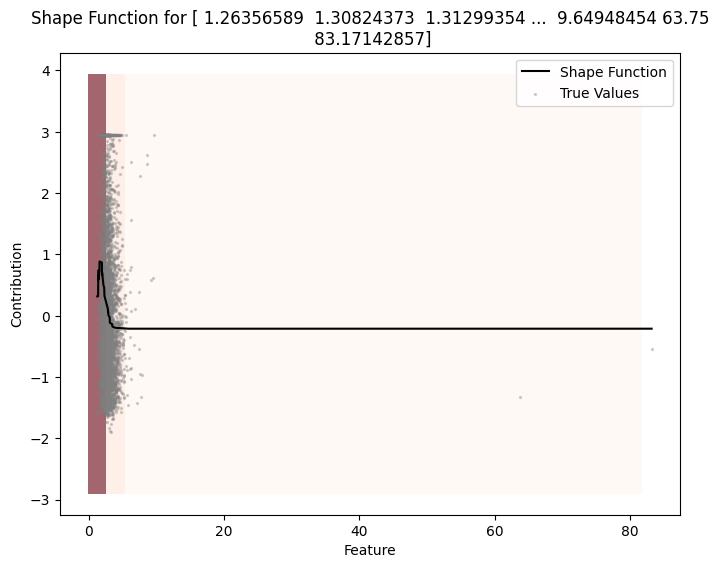

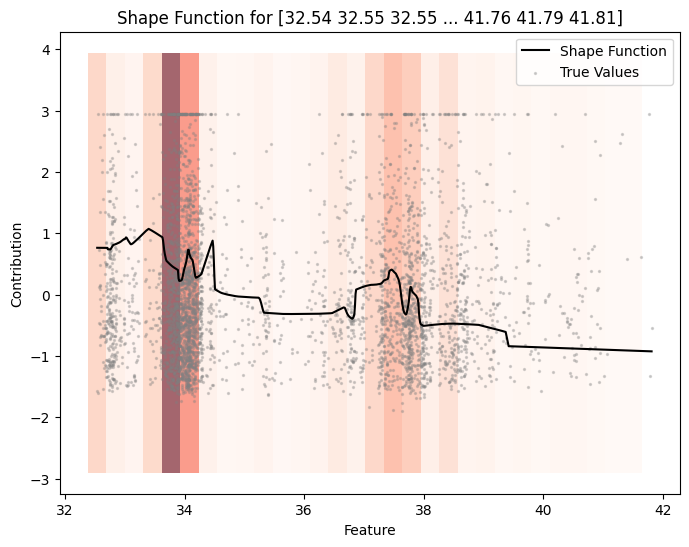

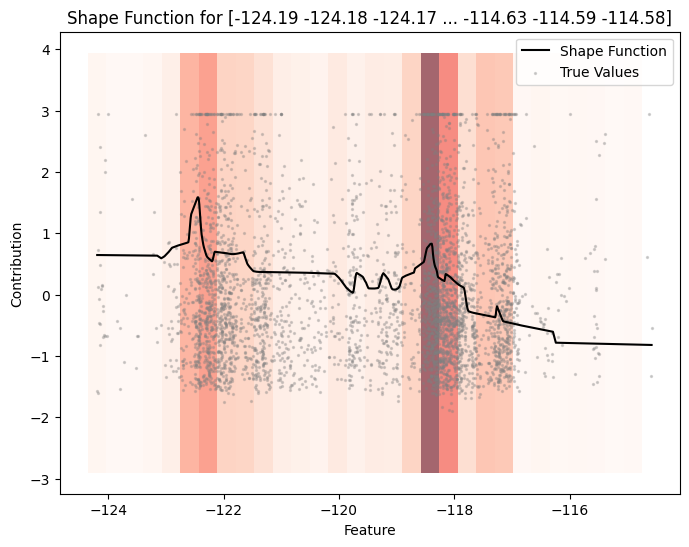

In [ ]:
model_housing.plot(X_test_h, y_test_h)